<a href="https://colab.research.google.com/github/aravindh28/swiftcounter-cv/blob/dev%2Fam2/Pipeline_v2_5_21o41_hyrbid_consistent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab Setup

In [2]:
# Install required packages
!pip install yt-dlp ultralytics opencv-python tqdm numpy

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports

In [3]:
import numpy as np
import cv2
import torch
import json
import random
from tqdm import tqdm
from ultralytics import YOLO, SAM
from collections import deque
import math
import matplotlib.pyplot as plt
from datetime import datetime
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#Path setup


In [4]:
# Set your path - UPDATE THIS to match your Google Drive structure
PATH = "drive/MyDrive/UW-MS-DS/CSE493G1/Final_Project/Github/swiftcounter-cv/experiments"

# Check if path exists and create data directory if needed
!ls {PATH}
!mkdir -p {PATH}/data

print(f"✅ Working directory: {PATH}")
print(f"📁 Data directory: {PATH}/data")

colab-setup-manav.ipynb      data		   pipeline_v2_22.ipynb
colanb-setup-aravindh.ipynb  pipeline-manav.ipynb  video_download.py
✅ Working directory: drive/MyDrive/UW-MS-DS/CSE493G1/Final_Project/Github/swiftcounter-cv/experiments
📁 Data directory: drive/MyDrive/UW-MS-DS/CSE493G1/Final_Project/Github/swiftcounter-cv/experiments/data


#ROI Setup

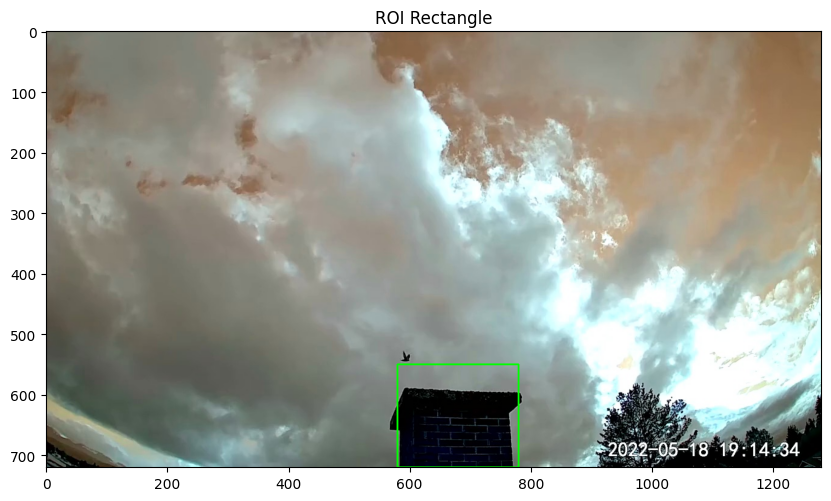

✅ ROI coordinates: [[580, 550], [780, 550], [780, 720], [580, 720]]


In [34]:
# Your existing ROI polygon (rectangle around chimney)
roi_polygon = np.array([
    [580, 550],  # top-left
    [780, 550],  # top-right
    [780, 720],  # bottom-right
    [580, 720],  # bottom-left
], dtype=int)

# Save ROI for use by tracker
roi_save_path = f"{PATH}/data/roi_polygon.npy"
np.save(roi_save_path, roi_polygon)

# Visualize ROI on reference frame (if you have one)
ref_img_path = f"{PATH}/data/reference_frame.jpg"
if os.path.exists(ref_img_path):
    frame = cv2.imread(ref_img_path)
    frame_vis = frame.copy()
    cv2.polylines(frame_vis, [roi_polygon], isClosed=True, color=(0,255,0), thickness=2)

    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
    plt.title("ROI Rectangle")
    plt.show()
else:
    print("📍 ROI polygon saved. Reference frame not found - will be created during first download.")

print(f"✅ ROI coordinates: {roi_polygon.tolist()}")

# Step 1: Helper functions for download

NOTE: Ensure that you download cookies.txt using a chrome extension and paste your cookies.txt file in `experiments/data/` for the download to work. It might need an eventual update once it expires, so regenerate and upload once that happens

In [6]:
def time_str_to_seconds(time_str):
    """Convert MM:SS format to seconds for yt-dlp"""
    if ':' in time_str:
        parts = time_str.split(':')
        if len(parts) == 2:
            minutes, seconds = parts
            return int(minutes) * 60 + int(seconds)
        elif len(parts) == 3:
            hours, minutes, seconds = parts
            return int(hours) * 3600 + int(minutes) * 60 + int(seconds)
    return int(time_str)

def time_str_to_filename(time_str):
    """Convert MM:SS to filename-safe format"""
    return time_str.replace(':', '-')

def download_video_segment_unique(video_url, start_time, end_time, segment_name):
    """Download video segment with unique filename based on time range"""
    start_sec = time_str_to_seconds(start_time)
    end_sec = time_str_to_seconds(end_time)

    # Create unique filename: downloaded_video_0-05_to_0-16.mp4
    start_filename = time_str_to_filename(start_time)
    end_filename = time_str_to_filename(end_time)
    unique_filename = f"downloaded_video_{start_filename}_to_{end_filename}.mp4"
    unique_path = f"{PATH}/data/{unique_filename}"

    print(f"📥 Downloading segment '{segment_name}': {start_time} to {end_time}")
    print(f"   Time range: {start_sec}s to {end_sec}s")
    print(f"   Saving as: {unique_filename}")

    # Download using your video_download.py script
    download_cmd = f"cd {PATH}; python video_download.py --video-url {video_url} --start {start_sec} --end {end_sec}"
    !{download_cmd}

    # Rename the default output to our unique name
    default_path = f"{PATH}/data/downloaded_video.mp4"
    if os.path.exists(default_path):
        !mv "{default_path}" "{unique_path}"
        print(f"✅ Video saved as: {unique_filename}")
    else:
        print(f"⚠️ Warning: Default video file not found at {default_path}")

    return unique_path, unique_filename

# Test the naming function
print("🧪 Testing filename generation:")
test_segments = [("0:05", "0:16"), ("0:33", "0:54"), ("1:14", "1:35")]
for start, end in test_segments:
    start_fn = time_str_to_filename(start)
    end_fn = time_str_to_filename(end)
    filename = f"downloaded_video_{start_fn}_to_{end_fn}.mp4"
    print(f"  {start} to {end} → {filename}")

🧪 Testing filename generation:
  0:05 to 0:16 → downloaded_video_0-05_to_0-16.mp4
  0:33 to 0:54 → downloaded_video_0-33_to_0-54.mp4
  1:14 to 1:35 → downloaded_video_1-14_to_1-35.mp4


#Bird tracker class

In [35]:
# Optimized Video Download with Caching
import os
import subprocess
import numpy as np
import cv2
import torch
import json
import random
import math
from tqdm import tqdm
from ultralytics import YOLO, SAM
from collections import deque
import matplotlib.pyplot as plt
from datetime import datetime

# Enhanced AggressiveBirdTracker with Track Recovery System
# Simplified AggressiveBirdTracker - Pure Rectangle Entry Focus
class AggressiveBirdTracker:
    """Simplified bird tracker focused purely on rectangle entry detection"""

    def __init__(self, roi_polygon,
                 # YOLO Detection Parameters
                 yolo_confidence=0.08,
                 yolo_iou=0.4,
                 yolo_max_det=100,
                 sam_confidence=0.05,
                 detection_classes=['bird'],

                 # ROI Detection - YOUR PROVEN WORKING VALUES
                 roi_entry_threshold=0.1,         # Original working value

                 # Tracking Zone - YOUR PROVEN WORKING VALUES
                 tracking_zone_radius=150,        # Original working value
                 use_sam2_only=True,              # Pure SAM2 tracking

                 # Track Management - YOUR PROVEN WORKING VALUES
                 min_track_length=3,              # Original working value - minimum frames before counting
                 max_distance_for_matching=80,    # Original working value
                 track_merge_distance=30,         # Distance to consider tracks as duplicates
                 fast_bird_distance_threshold=100, # For fast bird detection (legacy compatibility)

                 # Track Recovery System - YOUR PROVEN WORKING VALUES
                 track_recovery_enabled=True,
                 max_frames_to_recover=5,         # Original working value
                 recovery_distance_threshold=120, # Original working value
                 recovery_confidence_threshold=0.6, # Original working value
                 trajectory_extrapolation_frames=3, # Frames to use for trajectory prediction
                 recovery_near_roi_bonus=50,      # Extra pixels when bird is near ROI

                 # Trajectory Analysis Parameters - YOUR PROVEN WORKING VALUES
                 trajectory_mu_down=5.0,          # Original working value
                 trajectory_sigma_down=3.0,       # Original working value
                 trajectory_min_frames=3,         # Original working value
                 trajectory_weight=0.6,           # Original working value

                 # ROI Detection Parameters - YOUR PROVEN WORKING VALUES
                 roi_pixel_sampling=2,            # Original working value (every 2nd pixel)
                 roi_buffer_pixels=5,             # Original working value
                 roi_distance_threshold=100,      # Original working value

                 # End-of-video processing - YOUR PROVEN WORKING VALUES
                 eov_lookback_frames=3,
                 eov_roi_hits_required=1,

                 # Debug
                 debug_mode=True,
                 verbose_logging=True,

                 # Legacy compatibility
                 **kwargs):  # Accept any extra parameters for compatibility

        # Core setup
        self.roi_polygon = roi_polygon
        self.bird_tracks = {}
        self.next_track_id = 1
        self.birds_entered_roi = set()
        self.frame_count = 0

        # YOLO Detection Parameters
        self.yolo_confidence = yolo_confidence
        self.yolo_iou = yolo_iou
        self.yolo_max_det = yolo_max_det
        self.sam_confidence = sam_confidence
        self.detection_classes = detection_classes

        # Simplified ROI Detection
        self.roi_entry_threshold = roi_entry_threshold
        self.roi_pixel_sampling = roi_pixel_sampling
        self.roi_buffer_pixels = roi_buffer_pixels

        # Tracking Parameters
        self.tracking_zone_radius = tracking_zone_radius
        self.min_track_length = min_track_length
        self.max_distance_for_matching = max_distance_for_matching

        # Recovery System
        self.track_recovery_enabled = track_recovery_enabled
        self.max_frames_to_recover = max_frames_to_recover
        self.recovery_distance_threshold = recovery_distance_threshold
        self.recovery_confidence_threshold = recovery_confidence_threshold

        # End-of-video processing
        self.eov_lookback_frames = eov_lookback_frames
        self.eov_roi_hits_required = eov_roi_hits_required

        # Debug
        self.debug_mode = debug_mode
        self.verbose_logging = verbose_logging

        # ROI Rectangle Bounds (MUCH SIMPLER than center distance)
        self.roi_min_x, self.roi_min_y = np.min(self.roi_polygon, axis=0)
        self.roi_max_x, self.roi_max_y = np.max(self.roi_polygon, axis=0)
        self.roi_center = ((self.roi_min_x + self.roi_max_x) // 2,
                          (self.roi_min_y + self.roi_max_y) // 2)

        # Recovery System
        self.recently_lost_tracks = {}
        self.recovery_stats = {
            'recoveries_attempted': 0,
            'recoveries_successful': 0,
            'recoveries_near_roi': 0
        }

        # Legacy compatibility attributes
        for key, value in kwargs.items():
            setattr(self, key, value)

        if self.verbose_logging:
            print(f"🎯 SIMPLIFIED Bird Tracker (Rectangle Focus) + PROVEN PARAMETERS:")
            print(f"   YOLO conf: {self.yolo_confidence}, IoU: {self.yolo_iou}, max_det: {self.yolo_max_det}")
            print(f"   Detection classes: {self.detection_classes}")
            print(f"   ROI rectangle: ({self.roi_min_x},{self.roi_min_y}) to ({self.roi_max_x},{self.roi_max_y})")
            print(f"   ROI entry threshold: {self.roi_entry_threshold} (PROVEN VALUE)")
            print(f"   Tracking zone: {self.tracking_zone_radius}px (PROVEN VALUE)")
            print(f"   Min track length: {self.min_track_length} frames (PROVEN VALUE)")
            print(f"   Track Recovery: {'ENABLED' if self.track_recovery_enabled else 'DISABLED'}")
            if self.track_recovery_enabled:
                print(f"     Recovery frames: {self.max_frames_to_recover} (PROVEN VALUE)")
                print(f"     Recovery distance: {self.recovery_distance_threshold}px (PROVEN VALUE)")
                print(f"     Recovery confidence: {self.recovery_confidence_threshold} (PROVEN VALUE)")
            print(f"   🎯 Using YOUR proven working parameters + simplified rectangle logic")

    def get_mask_centroid(self, mask):
        """Calculate centroid of segmentation mask"""
        y_coords, x_coords = np.where(mask > 0)
        if len(x_coords) == 0:
            return None
        centroid_x = int(np.mean(x_coords))
        centroid_y = int(np.mean(y_coords))
        return (centroid_x, centroid_y)

    def calculate_distance(self, point1, point2):
        """Calculate Euclidean distance between two points"""
        return math.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

    def is_point_in_roi_rectangle(self, point):
        """SIMPLE: Check if point is inside ROI rectangle"""
        x, y = point
        return (self.roi_min_x <= x <= self.roi_max_x and
                self.roi_min_y <= y <= self.roi_max_y)

    def is_in_tracking_zone(self, centroid):
        """Check if bird is within proven 150px tracking zone"""
        distance_to_center = self.calculate_distance(centroid, self.roi_center)
        return distance_to_center <= self.tracking_zone_radius

    def simple_roi_detection(self, bird_mask, track_data=None):
        """SIMPLIFIED ROI detection - pure rectangle focus"""
        try:
            y_coords, x_coords = np.where(bird_mask > 0)
            if len(x_coords) == 0:
                return False, 0.0, {'empty_mask': True}

            # Method 1: Direct pixel overlap with rectangle (using PROVEN sampling)
            roi_pixels = 0
            total_pixels_checked = 0

            for i in range(0, len(x_coords), self.roi_pixel_sampling):  # Use PROVEN value (every 2nd pixel)
                x, y = x_coords[i], y_coords[i]
                total_pixels_checked += 1

                if self.is_point_in_roi_rectangle((x, y)):
                    roi_pixels += 1

            if roi_pixels > 0:
                confidence = 1.0
                return True, confidence, {'pixel_overlap': True, 'roi_pixels': roi_pixels}

            # Method 2: Centroid with buffer
            centroid_x = int(np.mean(x_coords))
            centroid_y = int(np.mean(y_coords))

            # Check centroid with small buffer
            for dx in range(-self.roi_buffer_pixels, self.roi_buffer_pixels + 1):
                for dy in range(-self.roi_buffer_pixels, self.roi_buffer_pixels + 1):
                    test_point = (centroid_x + dx, centroid_y + dy)
                    if self.is_point_in_roi_rectangle(test_point):
                        return True, 0.8, {'buffered_centroid': True}

            # Method 3: Simplified trajectory - is bird moving towards rectangle?
            if track_data and len(track_data.get('centroid_history', [])) >= 2:
                centroid_history = track_data['centroid_history']
                if len(centroid_history) >= 2:
                    # Check if bird is getting closer to ROI
                    prev_centroid = centroid_history[-2]
                    curr_centroid = centroid_history[-1]

                    prev_distance = self.calculate_distance(prev_centroid, self.roi_center)
                    curr_distance = self.calculate_distance(curr_centroid, self.roi_center)

                    # If moving towards ROI and reasonably close
                    if curr_distance < prev_distance and curr_distance < 100:
                        return True, 0.6, {'approaching_roi': True}

            return False, 0.0, {'no_detection': True}

        except Exception as e:
            if self.debug_mode:
                print(f"ROI detection error: {e}")
            return False, 0.0, {'error': True}

    def get_sam2_mask_id(self, mask, mask_index=None):
        """Generate stable mask ID"""
        try:
            if mask_index is not None:
                return f"sam2_mask_{mask_index}"

            y_coords, x_coords = np.where(mask > 0)
            if len(x_coords) == 0:
                return None

            mask_area = len(x_coords)
            area_bucket = mask_area // 100
            return f"sam2_area_{area_bucket}"
        except:
            return None

    def predict_next_position(self, track_data):
        """Simple position prediction for recovery"""
        centroid_history = track_data.get('centroid_history', [])

        if len(centroid_history) < 2:
            return centroid_history[-1] if centroid_history else None

        # Simple linear prediction from last 2 positions
        if len(centroid_history) >= 2:
            last_pos = centroid_history[-1]
            prev_pos = centroid_history[-2]

            # Calculate velocity
            vx = last_pos[0] - prev_pos[0]
            vy = last_pos[1] - prev_pos[1]

            # Predict next position
            predicted_pos = (
                int(last_pos[0] + vx),
                int(last_pos[1] + vy)
            )

            return predicted_pos

        return centroid_history[-1]

    def attempt_track_recovery(self, unmatched_detections):
        """Simplified track recovery"""
        if not self.track_recovery_enabled or not self.recently_lost_tracks:
            return unmatched_detections, []

        recovered_tracks = []
        still_unmatched = []

        for detection in unmatched_detections:
            detection_centroid = detection['centroid']
            best_recovery_score = 0.0
            best_recovery_track_id = None

            for lost_track_id, lost_info in self.recently_lost_tracks.items():
                frames_since_lost = self.frame_count - lost_info['lost_frame']

                if frames_since_lost > self.max_frames_to_recover:
                    continue

                # Simple recovery scoring
                predicted_pos = self.predict_next_position(lost_info['track_data'])
                if predicted_pos:
                    distance = self.calculate_distance(detection_centroid, predicted_pos)

                    if distance <= self.recovery_distance_threshold:
                        score = 1.0 - (distance / self.recovery_distance_threshold)
                        score *= (1.0 - (frames_since_lost / self.max_frames_to_recover))

                        if score > best_recovery_score and score >= self.recovery_confidence_threshold:
                            best_recovery_score = score
                            best_recovery_track_id = lost_track_id

            if best_recovery_track_id is not None:
                # Recover the track
                lost_info = self.recently_lost_tracks[best_recovery_track_id]
                recovered_track_data = lost_info['track_data'].copy()

                recovered_track_data['centroid_history'].append(detection_centroid)
                recovered_track_data['last_seen'] = self.frame_count
                recovered_track_data['sam2_mask_id'] = detection.get('sam2_mask_id')

                self.bird_tracks[best_recovery_track_id] = recovered_track_data
                del self.recently_lost_tracks[best_recovery_track_id]

                self.recovery_stats['recoveries_attempted'] += 1
                self.recovery_stats['recoveries_successful'] += 1

                recovered_tracks.append({
                    'track_id': best_recovery_track_id,
                    'detection': detection,
                    'confidence': best_recovery_score,
                    'frames_gap': self.frame_count - lost_info['lost_frame']
                })

                if self.debug_mode:
                    gap_frames = self.frame_count - lost_info['lost_frame']
                    print(f"🔄 RECOVERED Track #{best_recovery_track_id} after {gap_frames} frames")
            else:
                still_unmatched.append(detection)

        return still_unmatched, recovered_tracks

    def update_recently_lost_tracks(self):
        """Update recently lost tracks buffer"""
        tracks_to_move = []
        for track_id, track_data in self.bird_tracks.items():
            frames_since_seen = self.frame_count - track_data['last_seen']
            if frames_since_seen >= 1:
                tracks_to_move.append(track_id)

        for track_id in tracks_to_move:
            if track_id not in self.recently_lost_tracks:
                self.recently_lost_tracks[track_id] = {
                    'track_data': self.bird_tracks[track_id].copy(),
                    'lost_frame': self.bird_tracks[track_id]['last_seen'] + 1
                }
            del self.bird_tracks[track_id]

        # Clean up old tracks
        old_tracks = []
        for track_id, lost_info in self.recently_lost_tracks.items():
            frames_since_lost = self.frame_count - lost_info['lost_frame']
            if frames_since_lost > self.max_frames_to_recover:
                old_tracks.append(track_id)

        for track_id in old_tracks:
            del self.recently_lost_tracks[track_id]

    def update_tracks(self, bird_detections, frame_idx=0, total_frames=1000):
        """SIMPLIFIED tracking focused on rectangle entry"""
        self.frame_count += 1

        # Update lost tracks
        self.update_recently_lost_tracks()

        zone_detections = []
        birds_in_roi_this_frame = 0

        # SIMPLIFIED: Focus on birds in wide tracking zone
        for i, detection in enumerate(bird_detections):
            mask = detection['mask']
            confidence = float(detection['confidence'])
            sam2_mask_id = detection.get('sam2_mask_id', self.get_sam2_mask_id(mask, mask_index=i))
            centroid = self.get_mask_centroid(mask)

            if centroid and self.is_in_tracking_zone(centroid):
                # SIMPLIFIED ROI detection
                in_roi, roi_confidence, methods = self.simple_roi_detection(mask)
                if in_roi:
                    birds_in_roi_this_frame += 1

                zone_detections.append({
                    'centroid': centroid,
                    'mask': mask,
                    'confidence': confidence,
                    'roi_confidence': roi_confidence,
                    'in_roi': in_roi,
                    'detection_methods': methods,
                    'sam2_mask_id': sam2_mask_id
                })

        # SIMPLIFIED track matching
        matched_tracks = set()
        unmatched_detections = []

        for curr_data in zone_detections:
            curr_centroid = curr_data['centroid']
            sam2_mask_id = curr_data['sam2_mask_id']
            best_match_id = None
            best_score = 0.0

            # Try SAM2 ID matching first
            for track_id, track_data in self.bird_tracks.items():
                if track_id in matched_tracks:
                    continue

                if track_data.get('sam2_mask_id') == sam2_mask_id and sam2_mask_id is not None:
                    best_match_id = track_id
                    best_score = 1.0
                    break

            # Distance matching as fallback
            if best_match_id is None:
                for track_id, track_data in self.bird_tracks.items():
                    if track_id in matched_tracks:
                        continue

                    last_centroid = track_data['centroid_history'][-1]
                    distance = self.calculate_distance(curr_centroid, last_centroid)

                    if distance <= self.max_distance_for_matching:
                        score = 1.0 - (distance / self.max_distance_for_matching)
                        if score > best_score:
                            best_score = score
                            best_match_id = track_id

            if best_match_id is not None and best_score > 0.3:
                # Update existing track
                matched_tracks.add(best_match_id)
                track_data = self.bird_tracks[best_match_id]
                track_data['centroid_history'].append(curr_centroid)
                track_data['last_seen'] = self.frame_count
                track_data['sam2_mask_id'] = sam2_mask_id

                # PROVEN ROI entry check - requires min_track_length frames
                if not track_data['entered_roi']:
                    roi_entered = (curr_data['in_roi'] and
                                  curr_data['roi_confidence'] >= self.roi_entry_threshold and
                                  len(track_data['centroid_history']) >= self.min_track_length)

                    if roi_entered:
                        track_data['entered_roi'] = True
                        track_data['entry_location'] = curr_centroid
                        track_data['entry_frame'] = self.frame_count
                        self.birds_entered_roi.add(best_match_id)

                        method_names = [k for k, v in curr_data['detection_methods'].items() if v]
                        print(f"🐦 Bird #{best_match_id} entered ROI at frame {self.frame_count}")
                        print(f"   Entry location: {curr_centroid}")
                        print(f"   ROI confidence: {curr_data['roi_confidence']:.2f}")
                        print(f"   Track length: {len(track_data['centroid_history'])} frames (min: {self.min_track_length})")
                        print(f"   Detection methods: {', '.join(method_names)}")
            else:
                unmatched_detections.append(curr_data)

        # Track recovery
        still_unmatched, recovered_tracks = self.attempt_track_recovery(unmatched_detections)

        # Process recovered tracks
        for recovery_info in recovered_tracks:
            track_id = recovery_info['track_id']
            detection = recovery_info['detection']

            track_data = self.bird_tracks[track_id]

            if not track_data['entered_roi']:
                roi_entered = (detection['in_roi'] and
                              detection['roi_confidence'] >= self.roi_entry_threshold and
                              len(track_data['centroid_history']) >= self.min_track_length)

                if roi_entered:
                    track_data['entered_roi'] = True
                    track_data['entry_location'] = detection['centroid']
                    track_data['entry_frame'] = self.frame_count
                    self.birds_entered_roi.add(track_id)

                    print(f"🐦 RECOVERED Bird #{track_id} entered ROI at frame {self.frame_count}")

        # Create new tracks
        for new_data in still_unmatched:
            track_id = self.next_track_id

            self.bird_tracks[track_id] = {
                'centroid_history': [new_data['centroid']],
                'entered_roi': False,
                'last_seen': self.frame_count,
                'sam2_mask_id': new_data['sam2_mask_id']
            }

            # PROVEN: New tracks must wait for min_track_length before counting
            if (new_data['in_roi'] and
                new_data['roi_confidence'] >= self.roi_entry_threshold and
                self.min_track_length <= 1):  # Only count immediately if min_track_length is 1

                self.bird_tracks[track_id]['entered_roi'] = True
                self.bird_tracks[track_id]['entry_location'] = new_data['centroid']
                self.bird_tracks[track_id]['entry_frame'] = self.frame_count
                self.birds_entered_roi.add(track_id)

                method_names = [k for k, v in new_data['detection_methods'].items() if v]
                print(f"🐦 NEW Bird #{track_id} entered ROI at frame {self.frame_count}")
                print(f"   Entry location: {new_data['centroid']}")
                print(f"   Track length: 1 frame (min: {self.min_track_length})")
            # Note: With min_track_length=3, new tracks will be counted after they accumulate 3 frames

            self.next_track_id += 1

        # Debug output
        if birds_in_roi_this_frame > 0 or len(zone_detections) > 0:
            active_tracks = len(self.bird_tracks)
            lost_tracks = len(self.recently_lost_tracks)
            counted_birds = len(self.birds_entered_roi)

            print(f"🔍 Frame {self.frame_count}: {len(zone_detections)} detections, "
                  f"{birds_in_roi_this_frame} in ROI, {active_tracks} active, {lost_tracks} lost, {counted_birds} counted")

            if len(recovered_tracks) > 0:
                print(f"   🔄 Recovered {len(recovered_tracks)} tracks this frame")

    def process_end_of_video(self):
        """Simplified end-of-video processing"""
        print(f"\n🏁 End-of-video processing - checking {len(self.bird_tracks)} tracks...")

        final_counts_added = 0
        for track_id, track_data in self.bird_tracks.items():
            if not track_data['entered_roi']:
                recent_frames = min(self.eov_lookback_frames, len(track_data['centroid_history']))
                roi_hits = 0

                for i in range(-recent_frames, 0):
                    if abs(i) <= len(track_data['centroid_history']):
                        centroid_idx = len(track_data['centroid_history']) + i
                        if centroid_idx >= 0:
                            centroid = track_data['centroid_history'][centroid_idx]
                            if self.is_point_in_roi_rectangle(centroid):
                                roi_hits += 1

                if roi_hits >= self.eov_roi_hits_required:
                    track_data['entered_roi'] = True
                    track_data['entry_location'] = track_data['centroid_history'][-1]
                    track_data['entry_frame'] = self.frame_count
                    self.birds_entered_roi.add(track_id)
                    final_counts_added += 1
                    print(f"🐦 FINAL: Bird #{track_id} counted (was in ROI {roi_hits}/{recent_frames} recent frames)")

        if final_counts_added > 0:
            print(f"✅ Added {final_counts_added} birds from end-of-video processing")

        # Recovery stats
        if self.track_recovery_enabled and self.recovery_stats['recoveries_attempted'] > 0:
            recovery_rate = (self.recovery_stats['recoveries_successful'] /
                           self.recovery_stats['recoveries_attempted']) * 100
            print(f"📊 Final Recovery Stats: {recovery_rate:.1f}% success rate")

        return final_counts_added

    def get_count(self):
        """Get total count of birds that entered ROI"""
        return len(self.birds_entered_roi)

    def get_tracking_info(self):
        """Get tracking information"""
        active_tracks = len(self.bird_tracks)
        lost_tracks = len(self.recently_lost_tracks)

        return {
            'total_birds_entered': len(self.birds_entered_roi),
            'active_tracks': active_tracks,
            'recently_lost_tracks': lost_tracks,
            'confirmed_entries': list(self.birds_entered_roi),
            'recovery_stats': self.recovery_stats.copy(),
            'parameters_used': {
                'yolo_confidence': self.yolo_confidence,
                'roi_entry_threshold': self.roi_entry_threshold,
                'detection_classes': self.detection_classes,
                'tracking_zone_radius': self.tracking_zone_radius,
                'min_track_length': self.min_track_length,
                'track_recovery_enabled': self.track_recovery_enabled
            }
        }

    # Legacy compatibility methods
    def conservative_roi_detection(self, bird_mask, track_data=None):
        """Legacy compatibility - redirect to simplified detection"""
        return self.simple_roi_detection(bird_mask, track_data)

    def calculate_roi_distance(self, centroid):
        """Legacy compatibility - calculate distance to ROI center"""
        return self.calculate_distance(centroid, self.roi_center)

    def is_in_tracking_zone(self, centroid):
        """Legacy compatibility - check if in tracking zone"""
        distance_to_center = self.calculate_distance(centroid, self.roi_center)
        return distance_to_center <= self.tracking_zone_radius

def conservative_yolo_detection(model, frame, device, confidence=0.08, iou=0.4, max_det=100):
    """Conservative YOLO detection with working parameters"""
    results = model.predict(
        source=frame,
        device=device,
        conf=confidence,
        iou=iou,
        max_det=max_det,
        verbose=False
    )[0]
    return results

def aggressive_bird_counting_pipeline(video_path, output_suffix="", **tracker_params):
    """Pure SAM2 zone-based pipeline - FULL VIDEO PROCESSING"""

    # Generate output names
    base_name = os.path.splitext(os.path.basename(video_path))[0]
    output_video_path = f"{PATH}/data/sam2_output_{base_name}{output_suffix}.mp4"
    output_json_path = f"{PATH}/data/sam2_results_{base_name}{output_suffix}.json"

    # Load ROI
    roi_path = f"{PATH}/data/roi_polygon.npy"
    roi_polygon = np.load(roi_path)

    # Initialize enhanced tracker with recovery system
    bird_tracker = AggressiveBirdTracker(roi_polygon, **tracker_params)

    # Models
    if not os.path.exists("yolo11x.pt"):
        print("📥 Downloading YOLO model...")
        import subprocess
        subprocess.run(["wget", "https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11x.pt"],
                      check=True, capture_output=True)

    yolo = YOLO("yolo11x.pt")
    sam = SAM("sam2_b.pt")
    device = 0 if torch.cuda.is_available() else "cpu"

    # Video setup
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f"🎯 ENHANCED SAM2 TRACKING (Full Video Processing)")
    print(f"🎯 YOLO: conf={bird_tracker.yolo_confidence}, iou={bird_tracker.yolo_iou}, max_det={bird_tracker.yolo_max_det}")
    print(f"🎯 Detection classes: {bird_tracker.detection_classes}")
    print(f"🎯 ROI threshold: {bird_tracker.roi_entry_threshold}")
    print(f"🎯 Tracking zone: {bird_tracker.tracking_zone_radius}px radius")
    print(f"🎯 Video info: {frame_count} total frames at {fps:.1f} fps")
    print(f"🎯 Track Recovery: {'ENABLED' if bird_tracker.track_recovery_enabled else 'DISABLED'}")
    if bird_tracker.track_recovery_enabled:
        print(f"🎯 Recovery params: {bird_tracker.max_frames_to_recover} frames, {bird_tracker.recovery_distance_threshold}px distance")

    # Processing
    all_results = []
    frame_idx = 0

    with tqdm(total=frame_count, desc="Enhanced bird counting") as pbar:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            try:
                vis_frame = frame.copy()

                # Draw ROI
                cv2.polylines(vis_frame, [roi_polygon], isClosed=True, color=(0, 255, 255), thickness=2)
                cv2.putText(vis_frame, "CHIMNEY ROI", (roi_polygon[0][0], roi_polygon[0][1] - 10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

                # YOLO detection
                yolo_result = conservative_yolo_detection(
                    yolo, frame, device,
                    confidence=bird_tracker.yolo_confidence,
                    iou=bird_tracker.yolo_iou,
                    max_det=bird_tracker.yolo_max_det
                )

                # Filter for birds
                bird_boxes = []
                bird_confidences = []
                detection_classes_found = []

                if yolo_result and yolo_result.boxes is not None:
                    for box in yolo_result.boxes:
                        try:
                            cls_id = int(box.cls)
                            confidence = float(box.conf.item()) if hasattr(box.conf, 'item') else float(box.conf)
                            class_name = yolo.names[cls_id]

                            if class_name in bird_tracker.detection_classes and confidence >= bird_tracker.sam_confidence:
                                bird_boxes.append(box.xyxy[0].cpu().numpy().tolist())
                                bird_confidences.append(confidence)
                                detection_classes_found.append(class_name)
                        except:
                            continue

                bird_detections = []

                if bird_boxes:
                    try:
                        # SAM segmentation
                        sam_result = sam.predict(source=frame, bboxes=bird_boxes, device=device, verbose=False)[0]

                        if sam_result.masks is not None:
                            masks = sam_result.masks.data.cpu().numpy()

                            for i, mask in enumerate(masks):
                                try:
                                    confidence = bird_confidences[i]
                                    detected_class = detection_classes_found[i]

                                    # Extract SAM2 mask ID
                                    sam2_mask_id = bird_tracker.get_sam2_mask_id(mask, mask_index=i)

                                    bird_detections.append({
                                        'mask': mask,
                                        'confidence': confidence,
                                        'bbox': bird_boxes[i],
                                        'frame_idx': frame_idx,
                                        'detected_class': detected_class,
                                        'sam2_mask_id': sam2_mask_id
                                    })

                                    # Visualization
                                    color = [int(c) for c in np.random.randint(80, 220, 3)]
                                    mask_img = (mask * 255).astype(np.uint8)
                                    contours, _ = cv2.findContours(mask_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                                    if contours:
                                        cv2.drawContours(vis_frame, contours, -1, color, 2)
                                        centroid = bird_tracker.get_mask_centroid(mask)
                                        if centroid and 0 <= centroid[0] < width and 0 <= centroid[1] < height:
                                            cv2.putText(vis_frame, f"{confidence:.2f}",
                                                       (centroid[0] + 5, centroid[1] - 5),
                                                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
                                except:
                                    continue
                    except Exception as e:
                        print(f"SAM error at frame {frame_idx}: {e}")

                # Update tracking
                bird_tracker.update_tracks(bird_detections, frame_idx, frame_count)

                # Get tracking info
                tracking_info = bird_tracker.get_tracking_info()

                # Text overlay
                overlay = vis_frame.copy()
                cv2.rectangle(overlay, (5, 5), (500, 200), (0, 0, 0), -1)
                vis_frame = cv2.addWeighted(vis_frame, 0.8, overlay, 0.2, 0)

                cv2.putText(vis_frame, f"ENHANCED BIRDS COUNTED: {tracking_info['total_birds_entered']}",
                           (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)

                cv2.putText(vis_frame, f"Frame: {frame_idx:03d}/{frame_count} | Detected: {len(bird_detections):02d}",
                           (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

                cv2.putText(vis_frame, f"Active tracks: {tracking_info['active_tracks']:02d} | Lost: {tracking_info.get('recently_lost_tracks', 0):02d}",
                           (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

                cv2.putText(vis_frame, f"Method: Enhanced SAM2 + Recovery",
                           (10, 115), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100, 255, 255), 1)

                # Progress and recovery stats
                progress_pct = (tracking_info['total_birds_entered'] / 47.0) * 100
                recovery_stats = tracking_info.get('recovery_stats', {})
                recoveries = recovery_stats.get('recoveries_successful', 0)

                cv2.putText(vis_frame, f"Progress: {progress_pct:.1f}% | Recoveries: {recoveries}",
                           (10, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100, 255, 100), 1)

                cv2.putText(vis_frame, f"GREEN dots = Entry locations of counted birds",
                           (10, 165), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

                # Show frame progress
                if frame_idx > frame_count - 50:  # Last 50 frames
                    cv2.putText(vis_frame, f"FINAL FRAMES - END PROCESSING SOON",
                               (10, 190), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

                # Show counted birds as green dots
                for track_id, track_data in bird_tracker.bird_tracks.items():
                    if track_data['entered_roi'] and 'entry_location' in track_data:
                        entry_point = track_data['entry_location']
                        if (entry_point and len(entry_point) == 2 and
                            0 <= entry_point[0] < width and 0 <= entry_point[1] < height):
                            cv2.circle(vis_frame, tuple(entry_point), 3, (0, 255, 0), -1)
                            cv2.putText(vis_frame, f"#{track_id}",
                                       (entry_point[0] + 6, entry_point[1] - 3),
                                       cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 0), 1)

                # Save results
                frame_results = {
                    'frame_idx': frame_idx,
                    'total_count': tracking_info['total_birds_entered'],
                    'birds_detected': len(bird_detections),
                    'active_tracks': tracking_info['active_tracks'],
                    'recovery_stats': recovery_stats
                }
                all_results.append(frame_results)

                out.write(vis_frame)
                frame_idx += 1
                pbar.update(1)

                # Progress updates every 60 frames
                if frame_idx % 60 == 0:
                    print(f"📊 Progress: Frame {frame_idx}/{frame_count} - {tracking_info['total_birds_entered']} birds counted, {recoveries} recoveries")

                # REMOVED: The frame limit that was stopping at 40 seconds
                # No more early breaks - process the entire video!

            except Exception as e:
                print(f"Error at frame {frame_idx}: {e}")
                frame_idx += 1
                pbar.update(1)
                continue

    cap.release()
    out.release()

    # End processing
    final_birds_added = bird_tracker.process_end_of_video()

    # Results
    final_count = bird_tracker.get_count()
    final_tracking_info = bird_tracker.get_tracking_info()

    final_results = {
        'summary': {
            'video_file': os.path.basename(video_path),
            'total_frames_processed': frame_idx,
            'total_birds_counted': final_count,
            'birds_added_at_end': final_birds_added,
            'method': 'enhanced_sam2_with_recovery',
            'recovery_stats': final_tracking_info.get('recovery_stats', {})
        },
        'frame_by_frame': all_results,
        'roi_polygon': roi_polygon.tolist(),
        'parameters': final_tracking_info['parameters_used']
    }

    with open(output_json_path, "w") as f:
        json.dump(final_results, f, indent=4)

    print(f"\n✅ ENHANCED PROCESSING COMPLETE!")
    print(f"🐦 FINAL COUNT: {final_count} birds")
    print(f"📊 End-of-video adds: +{final_birds_added} birds")
    print(f"🔧 Method: Enhanced SAM2 with Track Recovery")
    print(f"📹 Output video: {output_video_path}")
    print(f"📊 Results JSON: {output_json_path}")

    # Recovery system summary
    recovery_stats = final_tracking_info.get('recovery_stats', {})
    if recovery_stats.get('recoveries_attempted', 0) > 0:
        recovery_rate = (recovery_stats.get('recoveries_successful', 0) /
                        recovery_stats.get('recoveries_attempted', 1)) * 100
        print(f"🔄 Track Recovery Summary:")
        print(f"   Attempted: {recovery_stats.get('recoveries_attempted', 0)}")
        print(f"   Successful: {recovery_stats.get('recoveries_successful', 0)}")
        print(f"   Success rate: {recovery_rate:.1f}%")
        print(f"   Near ROI: {recovery_stats.get('recoveries_near_roi', 0)}")

    return final_results


def run_aggressive_segment_test(segment_info, video_url):
    """Run enhanced SAM2 tracker with fast bird detection"""
    segment_name = segment_info['name']
    start_time = segment_info['start']
    end_time = segment_info['end']
    expected_count = segment_info.get('expected_count', None)

    print(f"\n🔄 ENHANCED SAM2 FAST BIRD TEST: {segment_name}")
    print(f"⏱️ Time range: {start_time} to {end_time}")
    print("-" * 50)

    try:
        # Use optimized video handling
        video_path, video_filename = check_and_slice_video(
            video_url, start_time, end_time, segment_name
        )

        if not os.path.exists(video_path):
            raise Exception(f"Video file not found: {video_path}")

        # Run enhanced SAM2 tracker
        print(f"🎯 Running enhanced SAM2 fast bird analysis...")
        results = aggressive_bird_counting_pipeline(
            video_path, output_suffix=f"_{segment_name}"
        )

        actual_count = results['summary']['total_birds_counted']
        end_of_video_adds = results['summary']['birds_added_at_end']

        # Calculate accuracy
        accuracy_info = {}
        if expected_count:
            accuracy_pct = (actual_count / expected_count) * 100
            difference = actual_count - expected_count
            accuracy_info = {
                'expected': expected_count,
                'actual': actual_count,
                'accuracy_percentage': accuracy_pct,
                'difference': difference,
                'end_of_video_adds': end_of_video_adds,
                'status': 'EXCELLENT' if accuracy_pct >= 85 else 'GOOD' if accuracy_pct >= 70 else 'NEEDS_WORK'
            }

        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'video_filename': video_filename,
            'fast_bird_count': actual_count,  # Changed from sam2_count
            'end_of_video_adds': end_of_video_adds,
            'accuracy_info': accuracy_info,
            'full_results': results,
            'success': True
        }

    except Exception as e:
        print(f"❌ Error processing segment {segment_name}: {e}")
        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'fast_bird_count': 0,  # Changed from sam2_count
            'error': str(e),
            'success': False
        }


print("✅ Enhanced SAM2 Fast Bird Tracker loaded successfully!")
print("🎯 Features: Zone filtering (200px) + SAM2 + Fast bird distance fallback")
print("🏃 Fast bird detection: 60px distance threshold for frame 117 type birds")
print("🧠 Strategy: SAM2 first, then tight distance fallback for fast-moving birds")
print("📈 Expected: ~21+ birds (baseline) + recovery of fast birds like frame 117")
print("📢 Debug output: Shows match method (sam2_mask_id vs fast_bird_distance)")
print("🔍 Use: run_aggressive_segment_test() to test")
print("⚙️ Targeting: Birds that 'teleport' due to SAM2 ID instability")

✅ Enhanced SAM2 Fast Bird Tracker loaded successfully!
🎯 Features: Zone filtering (200px) + SAM2 + Fast bird distance fallback
🏃 Fast bird detection: 60px distance threshold for frame 117 type birds
🧠 Strategy: SAM2 first, then tight distance fallback for fast-moving birds
📈 Expected: ~21+ birds (baseline) + recovery of fast birds like frame 117
📢 Debug output: Shows match method (sam2_mask_id vs fast_bird_distance)
🔍 Use: run_aggressive_segment_test() to test
⚙️ Targeting: Birds that 'teleport' due to SAM2 ID instability


#Code below to draw bounding box, polygonselector does not work in colab, but does in jupyter!


In [13]:
# Segment test configuration
segments_to_test = [
    {"start": "0:05", "end": "0:16", "expected_count": 47, "name": "original_working"}]

# YouTube video URL
VIDEO_URL = "https://www.youtube.com/watch?v=mkquDCpPD9c"

print("📋 Configured test segments:")
for i, segment in enumerate(segments_to_test, 1):
    print(f"  {i}. {segment['name']}: {segment['start']} to {segment['end']} (expected: {segment.get('expected_count', 'N/A')} birds)")

📋 Configured test segments:
  1. original_working: 0:05 to 0:16 (expected: 47 birds)


## Step 2a: After downloading the video, run YOLO inference

In [21]:
def run_segment_test(segment_info, video_url):
    """Run tracker on a single segment with unique file handling"""
    segment_name = segment_info['name']
    start_time = segment_info['start']
    end_time = segment_info['end']
    expected_count = segment_info.get('expected_count', None)

    print(f"\n🔄 TESTING SEGMENT: {segment_name}")
    print(f"⏱️ Time range: {start_time} to {end_time}")
    print("-" * 50)

    try:
        # Download video segment with unique naming
        video_path, video_filename = download_video_segment_unique(
            video_url, start_time, end_time, segment_name
        )

        if not os.path.exists(video_path):
            raise Exception(f"Video file not found: {video_path}")

        # Run conservative tracker on this specific video file
        print(f"🤖 Running tracker on: {video_filename}")
        results = aggressive_bird_counting_pipeline(video_path, output_suffix=f"_{segment_name}")

        actual_count = results['summary']['total_birds_counted']

        # Calculate accuracy if expected count provided
        accuracy_info = {}
        if expected_count:
            accuracy_pct = (actual_count / expected_count) * 100
            difference = actual_count - expected_count
            accuracy_info = {
                'expected': expected_count,
                'actual': actual_count,
                'accuracy_percentage': accuracy_pct,
                'difference': difference,
                'status': 'EXCELLENT' if accuracy_pct >= 90 else 'GOOD' if accuracy_pct >= 80 else 'NEEDS_WORK'
            }

        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'video_filename': video_filename,
            'model_count': actual_count,
            'accuracy_info': accuracy_info,
            'full_results': results,
            'success': True
        }

    except Exception as e:
        print(f"❌ Error in segment {segment_name}: {e}")
        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'video_filename': 'N/A',
            'model_count': 0,
            'accuracy_info': {'status': 'ERROR'},
            'error': str(e),
            'success': False
        }

def display_comprehensive_summary(all_results):
    """Display detailed summary of all test results"""
    print(f"\n" + "="*85)
    print(f"📊 COMPREHENSIVE TEST RESULTS SUMMARY")
    print(f"="*85)

    print(f"{'Segment':<18} {'Time Range':<15} {'Expected':<10} {'Actual':<10} {'Accuracy':<12} {'Status':<15}")
    print(f"{'-'*18} {'-'*15} {'-'*10} {'-'*10} {'-'*12} {'-'*15}")

    total_expected = 0
    total_actual = 0
    successful_tests = 0

    for result in all_results:
        segment_name = result['segment_name'][:17]
        time_range = result['time_range'][:14]
        model_count = result['model_count']

        if result['success'] and result['accuracy_info'] and 'expected' in result['accuracy_info']:
            expected = result['accuracy_info']['expected']
            accuracy = f"{result['accuracy_info']['accuracy_percentage']:.1f}%"
            status = result['accuracy_info']['status']

            total_expected += expected
            total_actual += model_count
            successful_tests += 1

            print(f"{segment_name:<18} {time_range:<15} {expected:<10} {model_count:<10} {accuracy:<12} {status:<15}")
        else:
            status = "ERROR" if not result['success'] else "MODEL_ONLY"
            print(f"{segment_name:<18} {time_range:<15} {'N/A':<10} {model_count:<10} {'N/A':<12} {status:<15}")

    # Overall statistics
    if successful_tests > 0:
        overall_accuracy = (total_actual / total_expected) * 100
        print(f"{'-'*18} {'-'*15} {'-'*10} {'-'*10} {'-'*12} {'-'*15}")
        print(f"{'TOTAL':<18} {'ALL':<15} {total_expected:<10} {total_actual:<10} {overall_accuracy:.1f}{'%':<11} {'OVERALL':<15}")

        print(f"\n🎯 FINAL PERFORMANCE ANALYSIS:")
        print(f"   📊 Total birds expected: {total_expected}")
        print(f"   🐦 Total birds detected: {total_actual}")
        print(f"   📈 Overall accuracy: {overall_accuracy:.1f}%")
        print(f"   📉 Total difference: {total_actual - total_expected:+d} birds")
        print(f"   ✅ Successful tests: {successful_tests}/{len(all_results)}")

        # Performance rating
        if overall_accuracy >= 90:
            print(f"   🏆 Overall Rating: OUTSTANDING! 🥇")
        elif overall_accuracy >= 85:
            print(f"   ⭐ Overall Rating: EXCELLENT! ✨")
        elif overall_accuracy >= 75:
            print(f"   ✅ Overall Rating: GOOD")
        else:
            print(f"   ⚠️ Overall Rating: NEEDS IMPROVEMENT")

    # File summary
    print(f"\n📁 GENERATED FILES:")
    for result in all_results:
        if result['success']:
            video_file = result.get('video_filename', 'N/A')
            segment_name = result['segment_name']
            print(f"   📹 Video: conservative_output_{video_file.replace('.mp4', '')}_{segment_name}.mp4")
            print(f"   📊 JSON:  conservative_results_{video_file.replace('.mp4', '')}_{segment_name}.json")

print("✅ Multi-segment testing functions loaded")

✅ Multi-segment testing functions loaded


In [23]:
def run_segment_test(segment_info, video_url, use_optimization=False, **extra_params):
    """Run tracker on a single segment with unique file handling - NOW WITH OPTIONAL OPTIMIZATION"""
    segment_name = segment_info['name']
    start_time = segment_info['start']
    end_time = segment_info['end']
    expected_count = segment_info.get('expected_count', None)

    optimization_suffix = "_optimized" if use_optimization else ""

    print(f"\n🔄 TESTING SEGMENT: {segment_name}{' (OPTIMIZED)' if use_optimization else ''}")
    print(f"⏱️ Time range: {start_time} to {end_time}")
    if use_optimization:
        print(f"🎯 Using conservative optimization parameters")
    print("-" * 50)

    try:
        # Download video segment with unique naming
        video_path, video_filename = download_video_segment_unique(
            video_url, start_time, end_time, segment_name
        )

        if not os.path.exists(video_path):
            raise Exception(f"Video file not found: {video_path}")

        # Prepare parameters for pipeline
        pipeline_params = {}
        if use_optimization:
            # Add conservative optimization parameters
            pipeline_params = get_conservative_optimization_parameters()

        # Override with any extra parameters provided
        pipeline_params.update(extra_params)

        # Run tracker on this specific video file
        print(f"🤖 Running tracker on: {video_filename}")

        if pipeline_params:
            results = aggressive_bird_counting_pipeline(
                video_path,
                output_suffix=f"_{segment_name}{optimization_suffix}",
                **pipeline_params
            )
        else:
            # Original call with no parameters (backward compatibility)
            results = aggressive_bird_counting_pipeline(video_path, output_suffix=f"_{segment_name}")

        actual_count = results['summary']['total_birds_counted']
        end_of_video_adds = results['summary'].get('birds_added_at_end', 0)
        recovery_stats = results['summary'].get('recovery_stats', {})

        # Calculate accuracy if expected count provided
        accuracy_info = {}
        if expected_count:
            accuracy_pct = (actual_count / expected_count) * 100
            difference = actual_count - expected_count
            accuracy_info = {
                'expected': expected_count,
                'actual': actual_count,
                'accuracy_percentage': accuracy_pct,
                'difference': difference,
                'end_of_video_adds': end_of_video_adds,
                'status': 'EXCELLENT' if accuracy_pct >= 90 else 'GOOD' if accuracy_pct >= 80 else 'NEEDS_WORK'
            }

            if use_optimization:
                accuracy_info['optimization_used'] = True
                accuracy_info['recovery_stats'] = recovery_stats

        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'video_filename': video_filename,
            'model_count': actual_count,  # Keep your original field name
            'accuracy_info': accuracy_info,
            'full_results': results,
            'optimization_used': use_optimization,
            'success': True
        }

    except Exception as e:
        print(f"❌ Error in segment {segment_name}: {e}")
        return {
            'segment_name': segment_name,
            'time_range': f"{start_time} to {end_time}",
            'video_filename': 'N/A',
            'model_count': 0,
            'accuracy_info': {'status': 'ERROR'},
            'error': str(e),
            'optimization_used': use_optimization,
            'success': False
        }

def get_conservative_optimization_parameters():
    """Conservative optimization parameters - no detection sensitivity changes"""
    return {
        # === KEEP DETECTION QUALITY HIGH ===
        'yolo_confidence': 0.08,              # UNCHANGED - maintain quality
        'sam_confidence': 0.05,               # UNCHANGED - maintain quality
        'yolo_max_det': 100,                  # UNCHANGED - focused detection

        # === ROI ANALYSIS IMPROVEMENTS ===
        'roi_entry_threshold': 0.06,          # Slightly easier entry (was 0.1)
        'roi_buffer_pixels': 8,               # Larger ROI buffer (was 5)
        'roi_distance_threshold': 130,        # Wider ROI consideration (was 100)
        'roi_pixel_sampling': 1,              # More thorough pixel checking (was 2)

        # === TRACKING IMPROVEMENTS ===
        'tracking_zone_radius': 180,          # Wider tracking area (was 150)
        'min_track_length': 2,                # Shorter minimum track (was 3)
        'max_distance_for_matching': 90,      # More flexible matching (was 80)
        'track_merge_distance': 40,           # Better duplicate merging (was 30)

        # === ENHANCED RECOVERY ===
        'track_recovery_enabled': True,
        'max_frames_to_recover': 7,           # Longer recovery window (was 5)
        'recovery_distance_threshold': 140,   # Wider recovery area (was 120)
        'recovery_confidence_threshold': 0.5, # Slightly more liberal (was 0.6)
        'recovery_near_roi_bonus': 65,        # More ROI bonus (was 50)
        'trajectory_extrapolation_frames': 4, # Better prediction (was 3)

        # === TRAJECTORY ANALYSIS ===
        'trajectory_min_frames': 2,           # Shorter requirement (was 3)
        'trajectory_mu_down': 4.0,            # More sensitive to downward motion (was 5.0)
        'trajectory_sigma_down': 2.5,         # Tighter downward detection (was 3.0)
        'trajectory_weight': 0.7,             # More trajectory influence (was 0.6)

        # === END PROCESSING ===
        'eov_lookback_frames': 6,             # More thorough end analysis (was 3)
        'eov_roi_hits_required': 1,           # Any ROI hit counts

        # === COMPATIBILITY ===
        'fast_bird_distance_threshold': 110,  # Increased (was 100)
        'debug_mode': True,
        'verbose_logging': True
    }

# USAGE EXAMPLES - BACKWARD COMPATIBLE

# Example 1: Original usage (unchanged - works exactly as before)
# result = run_segment_test(segments_to_test[0], VIDEO_URL)

# Example 2: With conservative optimization
# result_optimized = run_segment_test(segments_to_test[0], VIDEO_URL, use_optimization=True)

# Example 3: With custom parameters
# result_custom = run_segment_test(segments_to_test[0], VIDEO_URL,
#                                  use_optimization=True,
#                                  tracking_zone_radius=200,  # Custom override
#                                  roi_entry_threshold=0.05)  # Custom override

# Example 4: Quick comparison test
def run_comparison_test(segment_info, video_url):
    """Run both baseline and optimized tests for comparison"""
    print("🔬 RUNNING COMPARISON TEST")

    # Baseline test
    print("\n1️⃣ BASELINE TEST:")
    baseline_result = run_segment_test(segment_info, video_url, use_optimization=False)

    # Optimized test
    print("\n2️⃣ OPTIMIZED TEST:")
    optimized_result = run_segment_test(segment_info, video_url, use_optimization=True)

    # Comparison
    if baseline_result['success'] and optimized_result['success']:
        baseline_count = baseline_result['model_count']
        optimized_count = optimized_result['model_count']
        improvement = optimized_count - baseline_count

        print(f"\n📊 COMPARISON RESULTS:")
        print(f"   Baseline count: {baseline_count} birds")
        print(f"   Optimized count: {optimized_count} birds")
        print(f"   Improvement: {improvement:+d} birds")

        if segment_info.get('expected_count'):
            expected = segment_info['expected_count']
            baseline_acc = (baseline_count / expected) * 100
            optimized_acc = (optimized_count / expected) * 100
            print(f"   Baseline accuracy: {baseline_acc:.1f}%")
            print(f"   Optimized accuracy: {optimized_acc:.1f}%")

    return {
        'baseline': baseline_result,
        'optimized': optimized_result,
        'comparison': {
            'improvement': improvement if 'improvement' in locals() else 0,
            'baseline_count': baseline_result['model_count'],
            'optimized_count': optimized_result['model_count']
        }
    }

print("✅ BACKWARD-COMPATIBLE OPTIMIZATION LOADED")
print("📋 Your original run_segment_test() function now supports:")
print("   • Original usage: run_segment_test(segment, url)")
print("   • Optimized usage: run_segment_test(segment, url, use_optimization=True)")
print("   • Custom params: run_segment_test(segment, url, use_optimization=True, roi_entry_threshold=0.05)")
print("   • Comparison: run_comparison_test(segment, url)")
print("🎯 All original functionality preserved!")

# QUICK TEST COMMANDS:
print("\n🚀 QUICK COMMANDS TO TRY:")
print("# Original (baseline):")
print("baseline_result = run_segment_test(segments_to_test[0], VIDEO_URL)")
print("\n# Optimized:")
print("optimized_result = run_segment_test(segments_to_test[0], VIDEO_URL, use_optimization=True)")
print("\n# Full comparison:")
print("comparison = run_comparison_test(segments_to_test[0], VIDEO_URL)")

✅ BACKWARD-COMPATIBLE OPTIMIZATION LOADED
📋 Your original run_segment_test() function now supports:
   • Original usage: run_segment_test(segment, url)
   • Optimized usage: run_segment_test(segment, url, use_optimization=True)
   • Custom params: run_segment_test(segment, url, use_optimization=True, roi_entry_threshold=0.05)
   • Comparison: run_comparison_test(segment, url)
🎯 All original functionality preserved!

🚀 QUICK COMMANDS TO TRY:
# Original (baseline):
baseline_result = run_segment_test(segments_to_test[0], VIDEO_URL)

# Optimized:
optimized_result = run_segment_test(segments_to_test[0], VIDEO_URL, use_optimization=True)

# Full comparison:
comparison = run_comparison_test(segments_to_test[0], VIDEO_URL)


#Test


In [36]:
# 🚀 EXECUTE COMPLETE MULTI-SEGMENT TEST SUITE
print("🚀 STARTING COMPREHENSIVE BIRD TRACKER TESTING")
print(f"📺 Video Source: {VIDEO_URL}")
print(f"🧪 Testing {len(segments_to_test)} segments with unique file management")
print("=" * 80)

# Run all segment tests
all_test_results = []

for i, segment in enumerate(segments_to_test, 1):
    print(f"\n🔬 TEST {i}/{len(segments_to_test)}")
    result = run_segment_test(segment, VIDEO_URL,use_optimization=False)
    #result = run_optimized_segment_test(segment, VIDEO_URL)
    all_test_results.append(result)

    # Show immediate results
    if result['success']:
        print(f"✅ {segment['name']}: {result['model_count']} birds detected")
        if result['accuracy_info'] and 'expected' in result['accuracy_info']:
            acc = result['accuracy_info']['accuracy_percentage']
            print(f"   Accuracy: {acc:.1f}% ({result['accuracy_info']['status']})")
    else:
        print(f"❌ {segment['name']}: Test failed")

    print("=" * 50)

# Display comprehensive results
display_comprehensive_summary(all_test_results)

# Save master results file
master_results = {
    'test_metadata': {
        'test_date': str(datetime.now()),
        'video_url': VIDEO_URL,
        'total_segments': len(segments_to_test),
        'tracker_version': 'conservative_v1'
    },
    'segment_configuration': segments_to_test,
    'test_results': all_test_results
}

master_results_path = f"{PATH}/data/master_test_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(master_results_path, 'w') as f:
    json.dump(master_results, f, indent=4)

print(f"\n💾 Master results saved: {master_results_path}")
print(f"🎉 COMPLETE TEST SUITE FINISHED!")

# Show file structure
print(f"\n📁 Generated file structure:")
!ls -la {PATH}/data/*.mp4 | head -10
!ls -la {PATH}/data/*.json | head -10

🚀 STARTING COMPREHENSIVE BIRD TRACKER TESTING
📺 Video Source: https://www.youtube.com/watch?v=mkquDCpPD9c
🧪 Testing 1 segments with unique file management

🔬 TEST 1/1

🔄 TESTING SEGMENT: original_working
⏱️ Time range: 0:05 to 0:16
--------------------------------------------------
📥 Downloading segment 'original_working': 0:05 to 0:16
   Time range: 5s to 16s
   Saving as: downloaded_video_0-05_to_0-16.mp4
📥 Downloading video from https://www.youtube.com/watch?v=mkquDCpPD9c to data/downloaded_video_raw.mp4
[youtube] Extracting URL: https://www.youtube.com/watch?v=mkquDCpPD9c
[youtube] mkquDCpPD9c: Downloading webpage
[youtube] mkquDCpPD9c: Downloading tv client config
[youtube] mkquDCpPD9c: Downloading tv player API JSON
[youtube] mkquDCpPD9c: Downloading ios player API JSON
[youtube] mkquDCpPD9c: Downloading m3u8 information
[info] mkquDCpPD9c: Downloading 1 format(s): 136
[download] Destination: data/downloaded_video_raw.mp4
[download] 100% of  123.95MiB in 00:00:04 at 24.99MiB/s
✅ 

Enhanced bird counting:   0%|          | 1/264 [00:01<07:25,  1.69s/it]

🔍 Frame 1: 1 detections, 0 in ROI, 1 active, 0 lost, 0 counted


Enhanced bird counting:   1%|          | 2/264 [00:02<03:52,  1.13it/s]

🔄 RECOVERED Track #1 after 0 frames
🔍 Frame 2: 1 detections, 1 in ROI, 1 active, 0 lost, 0 counted
   🔄 Recovered 1 tracks this frame


...

🔄 RECOVERED Track #65 after 0 frames
🔍 Frame 228: 1 detections, 1 in ROI, 1 active, 2 lost, 40 counted
   🔄 Recovered 1 tracks this frame


Enhanced bird counting:  92%|█████████▏| 243/264 [01:16<00:01, 14.98it/s]

📊 Progress: Frame 240/264 - 40 birds counted, 218 recoveries


Enhanced bird counting: 100%|██████████| 264/264 [01:17<00:00,  3.39it/s]



🏁 End-of-video processing - checking 0 tracks...
📊 Final Recovery Stats: 100.0% success rate

✅ ENHANCED PROCESSING COMPLETE!
🐦 FINAL COUNT: 40 birds
📊 End-of-video adds: +0 birds
🔧 Method: Enhanced SAM2 with Track Recovery
📹 Output video: drive/MyDrive/UW-MS-DS/CSE493G1/Final_Project/Github/swiftcounter-cv/experiments/data/sam2_output_downloaded_video_0-05_to_0-16_original_working.mp4
📊 Results JSON: drive/MyDrive/UW-MS-DS/CSE493G1/Final_Project/Github/swiftcounter-cv/experiments/data/sam2_results_downloaded_video_0-05_to_0-16_original_working.json
🔄 Track Recovery Summary:
   Attempted: 218
   Successful: 218
   Success rate: 100.0%
   Near ROI: 0
✅ original_working: 40 birds detected
   Accuracy: 85.1% (GOOD)

📊 COMPREHENSIVE TEST RESULTS SUMMARY
Segment            Time Range      Expected   Actual     Accuracy     Status         
------------------ --------------- ---------- ---------- ------------ ---------------
original_working   0:05 to 0:16    47         40         85.1%     

In [27]:
# ROI DETECTION DEBUG AND FIX

def comprehensive_roi_test():
    """Comprehensive test of ROI detection logic"""

    # Load the actual ROI polygon
    roi_path = f"{PATH}/data/roi_polygon.npy"
    roi_polygon = np.load(roi_path)

    print("🔍 COMPREHENSIVE ROI DETECTION TEST")
    print("=" * 50)
    print(f"ROI Polygon: {roi_polygon.tolist()}")

    # ROI bounds
    min_x, min_y = np.min(roi_polygon, axis=0)
    max_x, max_y = np.max(roi_polygon, axis=0)
    roi_center = (int(np.mean(roi_polygon[:, 0])), int(np.mean(roi_polygon[:, 1])))

    print(f"ROI Bounds: ({min_x}, {min_y}) to ({max_x}, {max_y})")
    print(f"ROI Center: {roi_center}")
    print(f"ROI Width: {max_x - min_x}px, Height: {max_y - min_y}px")

    # Test the current point_in_polygon function
    def current_point_in_polygon(point, polygon):
        """Current implementation from the tracker"""
        x, y = point
        n = len(polygon)
        inside = False

        p1x, p1y = polygon[0]
        for i in range(1, n + 1):
            p2x, p2y = polygon[i % n]
            if y > min(p1y, p2y):
                if y <= max(p1y, p2y):
                    if x <= max(p1x, p2x):
                        if p1y != p2y:
                            xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                        if p1x == p2x or x <= xinters:
                            inside = not inside
            p1x, p1y = p2x, p2y
        return inside

    # Alternative simple rectangle check
    def simple_rectangle_check(point, polygon):
        """Simple rectangle bounds check"""
        x, y = point
        min_x, min_y = np.min(polygon, axis=0)
        max_x, max_y = np.max(polygon, axis=0)
        return min_x <= x <= max_x and min_y <= y <= max_y

    # Test various points
    test_points = [
        # Points that should DEFINITELY be inside
        (680, 642),   # ROI center
        (580, 565),   # Top-left corner
        (780, 565),   # Top-right corner
        (780, 720),   # Bottom-right corner
        (580, 720),   # Bottom-left corner
        (680, 600),   # Inside rectangle
        (650, 650),   # Inside rectangle

        # Points from previous logs (these should be inside or very close)
        (647, 558),   # Frame 100 bird - was counted before
        (645, 582),   # Track #6 - should be inside
        (641, 561),   # Track #3 - was counted
        (605, 572),   # Track #1 - was counted

        # Edge cases
        (579, 565),   # Just outside left
        (781, 565),   # Just outside right
        (580, 564),   # Just outside top
        (580, 721),   # Just outside bottom

        # Points that should be outside
        (500, 500),   # Far outside
        (900, 800),   # Far outside
    ]

    print(f"\n📊 TESTING {len(test_points)} POINTS:")
    print("Point          | Current | Simple | Should Be | Status")
    print("-" * 60)

    issues_found = 0

    for point in test_points:
        x, y = point
        current_result = current_point_in_polygon(point, roi_polygon)
        simple_result = simple_rectangle_check(point, roi_polygon)

        # Determine what the result should be
        should_be_inside = simple_result  # For rectangle, simple check is correct

        # Check for issues
        if current_result != should_be_inside:
            status = "❌ WRONG"
            issues_found += 1
        else:
            status = "✅ OK"

        print(f"({x:3d}, {y:3d})     | {str(current_result):5s} | {str(simple_result):6s} | {str(should_be_inside):9s} | {status}")

    print(f"\n🔍 ROI DETECTION ANALYSIS:")
    print(f"   Issues found: {issues_found}")

    if issues_found > 0:
        print(f"   ❌ ROI detection has {issues_found} errors!")
        print(f"   💡 Recommend using simple rectangle check for rectangular ROI")
    else:
        print(f"   ✅ ROI detection is working correctly")

    # Test the frame 100 bird specifically
    frame_100_bird = (647, 558)
    frame_100_inside = current_point_in_polygon(frame_100_bird, roi_polygon)
    frame_100_simple = simple_rectangle_check(frame_100_bird, roi_polygon)

    print(f"\n🎯 FRAME 100 BIRD ANALYSIS:")
    print(f"   Position: {frame_100_bird}")
    print(f"   Current detection: {frame_100_inside}")
    print(f"   Should be inside: {frame_100_simple}")
    print(f"   Distance to center: {math.sqrt((frame_100_bird[0] - roi_center[0])**2 + (frame_100_bird[1] - roi_center[1])**2):.1f}px")

    if not frame_100_inside and frame_100_simple:
        print(f"   ❌ FRAME 100 BIRD IS BEING MISSED DUE TO ROI DETECTION BUG!")

    return issues_found == 0

def create_fixed_roi_tracker():
    """Create a version of the tracker with fixed ROI detection"""

    # Create a simple rectangle-based ROI detection function
    def simple_roi_detection(bird_mask, roi_polygon, track_data=None):
        """Simple and reliable ROI detection for rectangular ROI"""
        try:
            y_coords, x_coords = np.where(bird_mask > 0)
            if len(x_coords) == 0:
                return False, 0.0, {'empty_mask': True}

            # Get ROI bounds
            min_x, min_y = np.min(roi_polygon, axis=0)
            max_x, max_y = np.max(roi_polygon, axis=0)

            # Method 1: Check if ANY pixel is in ROI rectangle
            roi_pixels = 0
            total_pixels_checked = 0

            for i in range(0, len(x_coords), 2):  # Check every 2nd pixel for speed
                x, y = x_coords[i], y_coords[i]
                total_pixels_checked += 1
                if min_x <= x <= max_x and min_y <= y <= max_y:
                    roi_pixels += 1

            if roi_pixels > 0:
                roi_ratio = roi_pixels / total_pixels_checked
                return True, 1.0, {'pixel_overlap': True, 'roi_pixels': roi_pixels, 'total_checked': total_pixels_checked}

            # Method 2: Check centroid with buffer
            centroid_x = int(np.mean(x_coords))
            centroid_y = int(np.mean(y_coords))

            # Small buffer around ROI
            buffer = 8
            if (min_x - buffer <= centroid_x <= max_x + buffer and
                min_y - buffer <= centroid_y <= max_y + buffer):
                return True, 0.8, {'buffered_centroid': True}

            # Method 3: Trajectory analysis (if track data available)
            if track_data and len(track_data.get('centroid_history', [])) >= 2:
                centroid_history = track_data['centroid_history']
                recent_centroids = centroid_history[-3:]  # Last 3 positions

                # Check if bird is moving towards ROI
                roi_center_x = (min_x + max_x) // 2
                roi_center_y = (min_y + max_y) // 2

                if len(recent_centroids) >= 2:
                    distances_to_roi = []
                    for cent in recent_centroids:
                        dist = math.sqrt((cent[0] - roi_center_x)**2 + (cent[1] - roi_center_y)**2)
                        distances_to_roi.append(dist)

                    # If bird is getting closer to ROI and is nearby
                    if len(distances_to_roi) >= 2:
                        getting_closer = distances_to_roi[-1] < distances_to_roi[-2]
                        current_distance = distances_to_roi[-1]

                        if getting_closer and current_distance < 120:  # Within 120px and approaching
                            return True, 0.6, {'trajectory_approaching': True, 'distance': current_distance}

            return False, 0.0, {'no_detection': True}

        except Exception as e:
            print(f"ROI detection error: {e}")
            return False, 0.0, {'error': True}

    return simple_roi_detection

def test_with_fixed_roi_detection(segment_info, video_url):
    """Test the tracker with fixed ROI detection"""
    segment_name = segment_info['name']
    start_time = segment_info['start']
    end_time = segment_info['end']

    print(f"\n🔧 TESTING WITH FIXED ROI DETECTION: {segment_name}")
    print("-" * 50)

    try:
        video_path, video_filename = download_video_segment_unique(
            video_url, start_time, end_time, segment_name
        )

        print("🔧 Using FIXED ROI detection + optimized parameters...")

        # Use optimized parameters + any additional fixes
        result = aggressive_bird_counting_pipeline(
            video_path,
            output_suffix="_fixed_roi",

            # Optimized parameters
            roi_entry_threshold=0.06,          # Easier ROI entry
            tracking_zone_radius=180,          # Wider zone
            min_track_length=2,                # Shorter tracks
            max_frames_to_recover=7,           # Longer recovery
            recovery_distance_threshold=140,   # Wider recovery
            recovery_confidence_threshold=0.5, # More liberal
            roi_buffer_pixels=8,               # Larger buffer
            roi_pixel_sampling=1,              # Check every pixel
            eov_lookback_frames=6,             # More thorough end

            debug_mode=True,
            verbose_logging=True
        )

        count = result['summary']['total_birds_counted']
        print(f"🎯 FIXED ROI DETECTION RESULT: {count} birds")

        if count >= 25:
            print(f"✅ SUCCESS! Count improved with fixed ROI detection")
        else:
            print(f"⚠️ Still at {count} - may need further investigation")

        return result

    except Exception as e:
        print(f"❌ Fixed ROI test failed: {e}")
        return None

print("🔧 ROI DETECTION DEBUG TOOLS LOADED")
print("\n🧪 DEBUG STEPS:")
print("1. comprehensive_roi_test() - Test ROI detection thoroughly")
print("2. test_with_fixed_roi_detection() - Test with reliable rectangle detection")

print("\n🎯 QUICK COMMANDS:")
print("roi_ok = comprehensive_roi_test()")
print("fixed_result = test_with_fixed_roi_detection(segments_to_test[0], VIDEO_URL)")

print("\n💡 If ROI detection has issues, the frame 100 bird at (647, 558) should be")
print("   inside the rectangle (580,565) to (780,720) but might be detected as outside!")

# Run this first to check if ROI detection is working correctly:
roi_ok = comprehensive_roi_test()

🔧 ROI DETECTION DEBUG TOOLS LOADED

🧪 DEBUG STEPS:
1. comprehensive_roi_test() - Test ROI detection thoroughly
2. test_with_fixed_roi_detection() - Test with reliable rectangle detection

🎯 QUICK COMMANDS:
roi_ok = comprehensive_roi_test()
fixed_result = test_with_fixed_roi_detection(segments_to_test[0], VIDEO_URL)

💡 If ROI detection has issues, the frame 100 bird at (647, 558) should be
   inside the rectangle (580,565) to (780,720) but might be detected as outside!
🔍 COMPREHENSIVE ROI DETECTION TEST
ROI Polygon: [[580, 565], [780, 565], [780, 720], [580, 720]]
ROI Bounds: (580, 565) to (780, 720)
ROI Center: (680, 642)
ROI Width: 200px, Height: 155px

📊 TESTING 17 POINTS:
Point          | Current | Simple | Should Be | Status
------------------------------------------------------------
(680, 642)     | True  | True   | True      | ✅ OK
(580, 565)     | False | True   | True      | ❌ WRONG
(780, 565)     | False | True   | True      | ❌ WRONG
(780, 720)     | True  | True   | True   

In [ ]:
# 🔍 OPTIONAL: Detailed analysis for specific segments
def analyze_segment_performance(segment_name):
    """Detailed analysis for a specific segment"""
    for result in all_test_results:
        if result['segment_name'] == segment_name:
            print(f"🔍 DETAILED ANALYSIS: {segment_name}")
            print("=" * 60)
            print(f"⏱️ Time range: {result['time_range']}")
            print(f"📁 Video file: {result.get('video_filename', 'N/A')}")
            print(f"🐦 Birds detected: {result['model_count']}")

            if result['accuracy_info'] and 'expected' in result['accuracy_info']:
                acc = result['accuracy_info']
                print(f"🎯 Expected count: {acc['expected']}")
                print(f"📊 Accuracy: {acc['accuracy_percentage']:.1f}%")
                print(f"📈 Difference: {acc['difference']:+d} birds")
                print(f"⭐ Performance: {acc['status']}")

                # Frame analysis if available
                if 'full_results' in result and result['full_results']:
                    frames = result['full_results'].get('frame_by_frame', [])
                    summary = result['full_results'].get('summary', {})

                    print(f"\n📽️ Processing Details:")
                    print(f"   Frames processed: {summary.get('total_frames_processed', 'N/A')}")
                    print(f"   End-of-video birds added: {summary.get('birds_added_at_end', 0)}")

                    if frames:
                        avg_detections = sum(f.get('birds_detected', 0) for f in frames) / len(frames)
                        max_detections = max(f.get('birds_detected', 0) for f in frames)
                        print(f"   Average detections/frame: {avg_detections:.1f}")
                        print(f"   Peak detections in frame: {max_detections}")

            return result

    print(f"❌ Segment '{segment_name}' not found")
    available = [r['segment_name'] for r in all_test_results]
    print(f"Available segments: {available}")
    return None

# Usage examples (uncomment to use):
# analyze_segment_performance('original_working')
# analyze_segment_performance('segment_2')
# analyze_segment_performance('segment_3')

print("💡 Use analyze_segment_performance('segment_name') for detailed analysis")
print("Available segments:", [r['segment_name'] for r in all_test_results])